# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
#Type your code here
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_selector as selector
import joblib
import numpy as np
import math

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
#Type your code here
df = pd.read_csv('/Users/yudisdwi/Documents/Eksperimen_SML_Yudisdwi/dataset/data.csv', sep=';')
df

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

Output pada cell sebelumnya (`df.info()`) memberikan informasi mengenai struktur DataFrame. Berikut penjelasannya:

- **Jumlah kolom**: Terdapat 37 kolom pada DataFrame.
- **Nama kolom dan tipe data**: Setiap kolom ditampilkan beserta jumlah data yang tidak kosong (non-null) dan tipe datanya (`int64`, `float64`, atau `object`). masih banyak yang belum sesuai dengan tipe datanya.
- **Jumlah baris**: Terdapat 4424 baris data.
- **Kolom 'Status'**: Bertipe `object`, yang akan menjadi data target yang merupakan data status siswa.

Secara umum, output ini membantu memahami tipe data, jumlah data, dan tidak ada data yang hilang pada setiap kolom.

In [4]:
# Definisikan semua fitur sebelum preprocessing
numeric_features = [
    'Application_order', 'Previous_qualification_grade', 'Admission_grade',
    'Age_at_enrollment', 'Curricular_units_1st_sem_credited',
    'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations',
    'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
    'Curricular_units_1st_sem_without_evaluations',
    'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled',
    'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations',
    'Unemployment_rate', 'Inflation_rate', 'GDP'
]

ordinal_features = [
    'Marital_status', 'Mothers_qualification', 'Fathers_qualification'
]

nominal_features = [
    'Application_mode', 'Course', 'Daytime_evening_attendance',
    'Previous_qualification', 'Nacionality',
    'Mothers_occupation', 'Fathers_occupation',
    'Displaced', 'Educational_special_needs', 'Debtor',
    'Tuition_fees_up_to_date', 'Gender',
    'Scholarship_holder', 'International'
]

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [5]:
# Cek missing values
print("Missing values per kolom:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Dataset ini tidak memiliki missing values, tetapi sebagai antisipasi:
# Untuk kolom numerik → isi dengan median
for col in numeric_features:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Untuk kolom kategorikal → isi dengan modus
for col in ordinal_features + nominal_features:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing values setelah penanganan:")
print(df.isnull().sum().sum())

Missing values per kolom:
Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment       

In [6]:
print(f"Jumlah baris sebelum drop duplikat: {df.shape[0]}")

df.drop_duplicates(inplace=True)

print(f"Jumlah baris setelah drop duplikat: {df.shape[0]}")

Jumlah baris sebelum drop duplikat: 4424
Jumlah baris setelah drop duplikat: 4424


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Standarisasi hanya pada fitur numerik yang relevan
df_scaled = df.copy()
df_scaled[numeric_features] = scaler.fit_transform(df[numeric_features])

print("Statistik fitur numerik setelah standarisasi:")
df_scaled[numeric_features].describe().round(2)

Statistik fitur numerik setelah standarisasi:


,Application_order,Previous_qualification_grade,Admission_grade,Age_at_enrollment,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00
mean,-0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.32,-2.85,-2.21,-0.83,-0.30,-2.53,-1.99,-1.52,-2.20,-0.20,-0.28,-2.84,-2.04,-1.47,-1.96,-0.20,-1.49,-1.47,-1.79
25%,-0.55,-0.58,-0.63,-0.56,-0.30,-0.51,-0.55,-0.55,0.07,-0.20,-0.28,-0.56,-0.52,-0.81,0.10,-0.20,-0.81,-0.67,-0.75
50%,-0.55,0.04,-0.06,-0.43,-0.30,-0.11,-0.07,0.09,0.34,-0.20,-0.28,-0.11,-0.02,0.19,0.38,-0.20,-0.18,0.12,0.14
75%,0.21,0.56,0.54,0.23,-0.30,0.29,0.41,0.42,0.57,-0.20,-0.28,0.35,0.49,0.52,0.60,-0.20,0.88,0.99,0.79
max,5.54,4.35,4.35,6.16,8.17,7.96,8.78,6.88,1.70,17.17,9.62,7.64,6.32,5.16,1.60,15.72,1.74,1.79,1.55


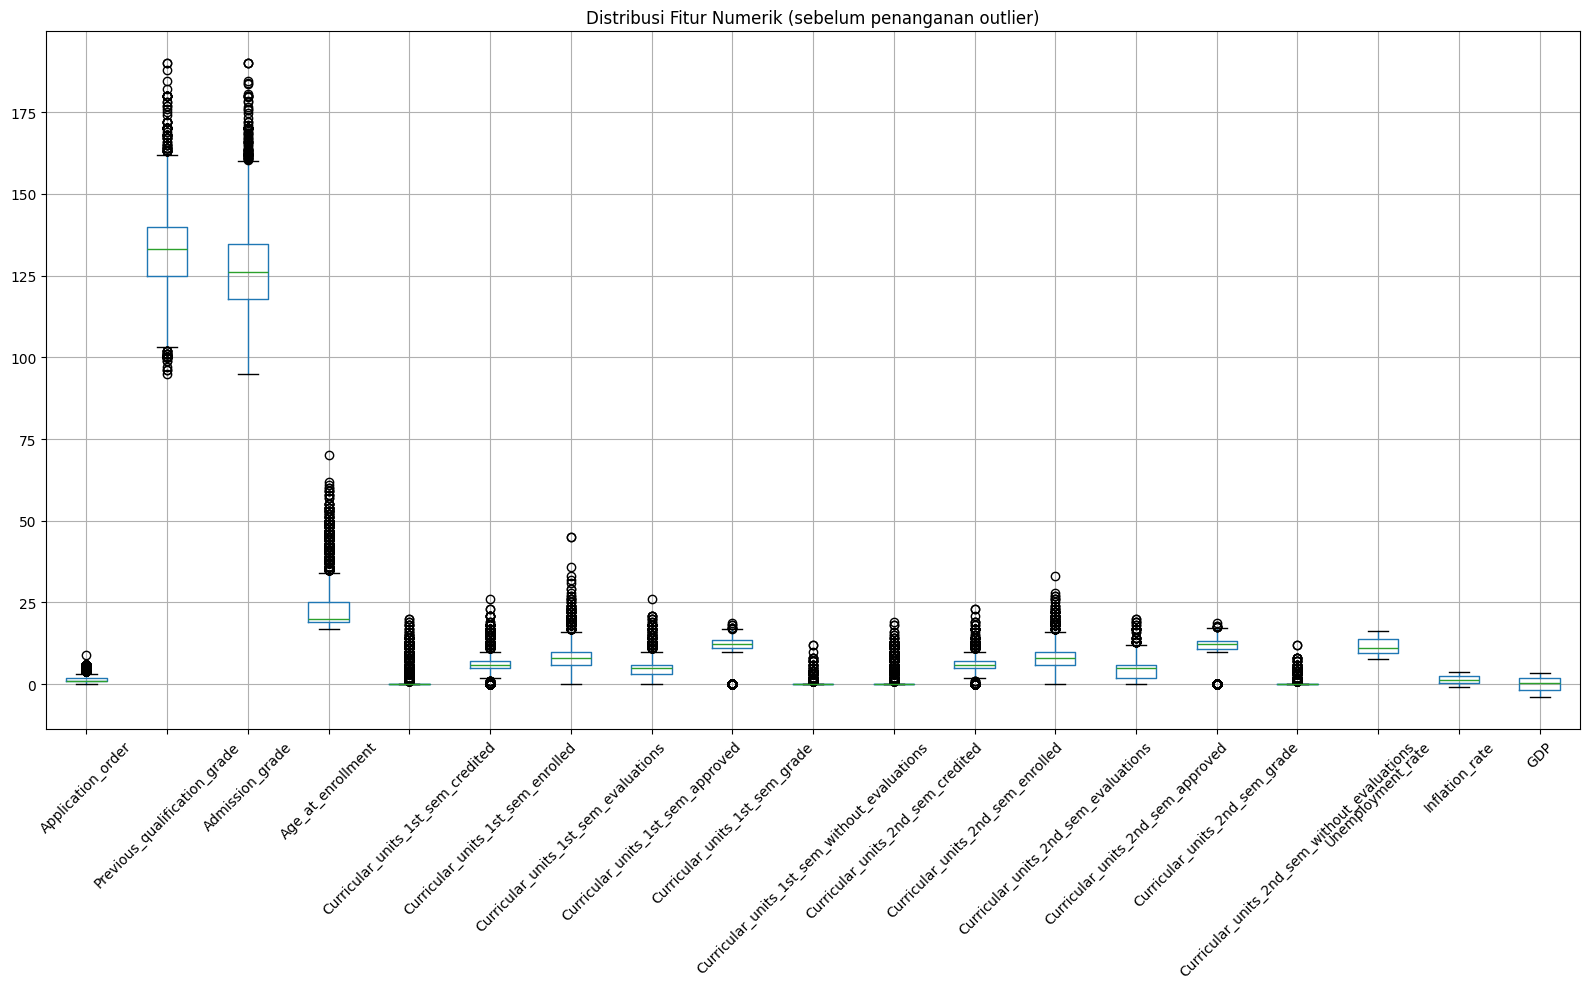

Jumlah baris dihapus karena outlier: 2422
Jumlah baris tersisa: 2002


In [8]:
# Deteksi outlier menggunakan metode IQR
Q1 = df[numeric_features].quantile(0.25)
Q3 = df[numeric_features].quantile(0.75)
IQR = Q3 - Q1

# Visualisasi outlier sebelum penanganan
plt.figure(figsize=(16, 10))
df[numeric_features].boxplot(rot=45)
plt.title("Distribusi Fitur Numerik (sebelum penanganan outlier)")
plt.tight_layout()
plt.show()

# Filter baris yang tidak mengandung outlier
condition = ~((df[numeric_features] < (Q1 - 1.5 * IQR)) | 
              (df[numeric_features] > (Q3 + 1.5 * IQR))).any(axis=1)

df_no_outlier = df[condition].reset_index(drop=True)

print(f"Jumlah baris dihapus karena outlier: {df.shape[0] - df_no_outlier.shape[0]}")
print(f"Jumlah baris tersisa: {df_no_outlier.shape[0]}")

In [12]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

df_encoded = df_no_outlier.copy()

# --- Ordinal Encoding (kolom masih integer, pakai urutan nilai yang ada) ---
ordinal_mappings = [
    sorted(df_encoded['Marital_status'].unique().tolist()),
    sorted(df_encoded['Mothers_qualification'].unique().tolist()),
    sorted(df_encoded['Fathers_qualification'].unique().tolist()),
]

oe = OrdinalEncoder(categories=ordinal_mappings, handle_unknown='use_encoded_value', unknown_value=-1)
df_encoded[ordinal_features] = oe.fit_transform(df_encoded[ordinal_features])

# --- One-Hot Encoding untuk fitur nominal ---
df_encoded = pd.get_dummies(df_encoded, columns=nominal_features, drop_first=False)

# --- Label Encoding untuk target ---
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_encoded['Status'] = le.fit_transform(df_encoded['Status'])

print("Kelas target:", le.classes_)
print(f"\nShape setelah encoding: {df_encoded.shape}")
df_encoded.head()

Kelas target: ['Dropout' 'Enrolled' 'Graduate']

Shape setelah encoding: (2002, 163)


,Marital_status,Application_order,Previous_qualification_grade,Mothers_qualification,Fathers_qualification,Admission_grade,Age_at_enrollment,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,...,Debtor_0,Debtor_1,Tuition_fees_up_to_date_0,Tuition_fees_up_to_date_1,Gender_0,Gender_1,Scholarship_holder_0,Scholarship_holder_1,International_0,International_1
0,0.0,1,160.0,0.0,2.0,142.5,19,0,6,6,...,True,False,True,False,False,True,True,False,True,False
1,0.0,2,122.0,16.0,14.0,119.6,20,0,6,8,...,True,False,False,True,True,False,True,False,True,False
2,0.0,1,142.0,10.0,15.0,128.4,18,0,7,9,...,True,False,False,True,True,False,False,True,True,False
3,0.0,3,137.0,0.0,0.0,129.3,21,0,6,8,...,True,False,False,True,True,False,False,True,False,True
4,0.0,1,138.0,0.0,8.0,123.0,18,0,6,9,...,False,True,True,False,True,False,True,False,True,False


Distribusi Admission Grade per kategori:
Admission_grade_bin
Medium       1125
Low           632
High          244
Very High       1
Name: count, dtype: int64

Distribusi Kelompok Umur:
Age_group
18-20    1479
21-25     348
26-35     174
35+         0
Name: count, dtype: int64


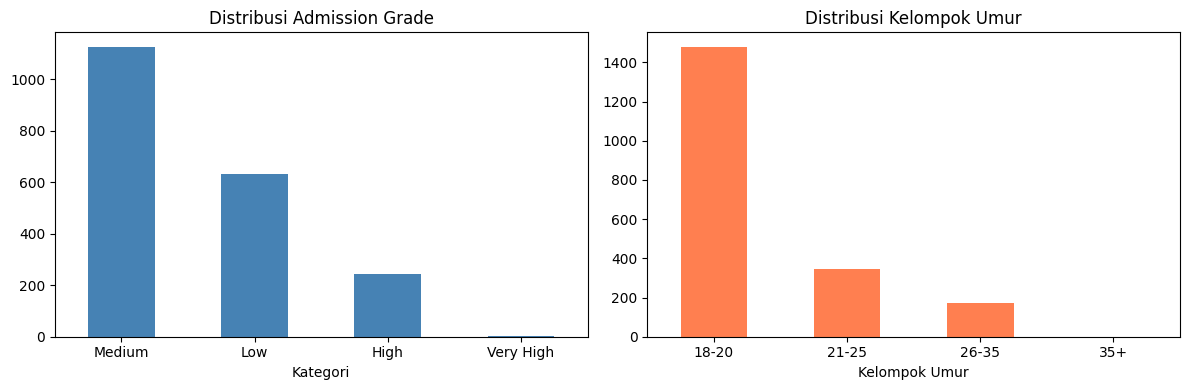

In [17]:
# Binning pada fitur Admission_grade menjadi 4 kategori
df_encoded['Admission_grade_bin'] = pd.cut(
    df_no_outlier['Admission_grade'],
    bins=[0, 120, 140, 160, 200],
    labels=['Low', 'Medium', 'High', 'Very High']
)

print("Distribusi Admission Grade per kategori:")
print(df_encoded['Admission_grade_bin'].value_counts())

# Binning pada Age_at_enrollment
df_encoded['Age_group'] = pd.cut(
    df_no_outlier['Age_at_enrollment'],
    bins=[17, 20, 25, 35, 70],
    labels=['18-20', '21-25', '26-35', '35+']
)

print("\nDistribusi Kelompok Umur:")
print(df_encoded['Age_group'].value_counts())

# Visualisasi hasil binning
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_encoded['Admission_grade_bin'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribusi Admission Grade')
axes[0].set_xlabel('Kategori')
axes[0].tick_params(axis='x', rotation=0)

df_encoded['Age_group'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Distribusi Kelompok Umur')
axes[1].set_xlabel('Kelompok Umur')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Simpan hasil akhir
df_encoded.to_csv("clean_data.csv", index=False)